# Gradient Boosting

В ноутбуке посмотрим:
- Что такое **градиентный бустинг**
- Чем **градиентный бустинг** отличается от **Random Forest**
- Как влияют гиперпараметры, и какие метрики/графики важны
- Идею **бустинга**
- Идею **бэггинга**

## 1. Импорт библиотек

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier

def make_gb(**kw):
  return LGBMClassifier(random_state=42, verbose=-1, **kw)

plt.rcParams["figure.figsize"] = (8, 5)
RND = 42

## 2. Данные
Возьмём датасет **Breast Cancer**.

In [38]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RND
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
X.head()

Train: (455, 30), Test: (114, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Random Forest vs Gradient Boosting

In [39]:
rf = RandomForestClassifier(n_estimators=200, random_state=RND).fit(X_train, y_train)
gb = make_gb(n_estimators=200, learning_rate=0.1).fit(X_train, y_train)

for name, m in [("Random Forest", rf), ('LightGBM', gb)]:
    acc = accuracy_score(y_test, m.predict(X_test))
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    print(f"{name:25s}  Accuracy={acc:.4f}  ROC-AUC={auc:.4f}")

Random Forest              Accuracy=0.9561  ROC-AUC=0.9931
LightGBM                   Accuracy=0.9561  ROC-AUC=0.9891


## 4. Как модель обучается последовательно
Посмотрим, как растёт качество с добавлением каждого нового дерева.

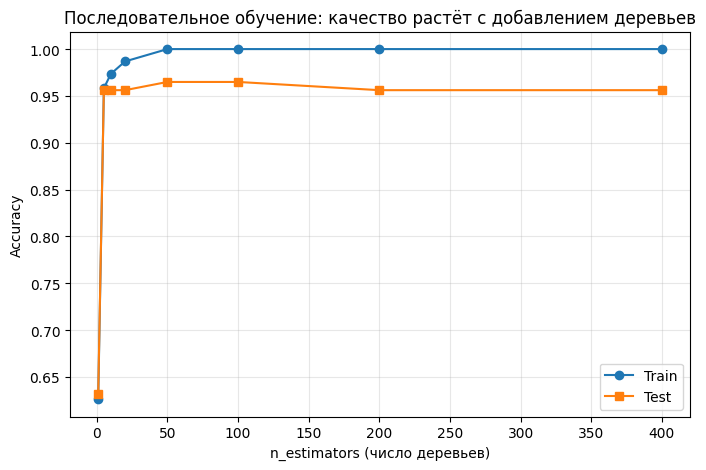

In [40]:
n_steps = [1, 5, 10, 20, 50, 100, 200, 400]
train_scores, test_scores = [], []

for n in n_steps:
    m = make_gb(n_estimators=n, learning_rate=0.1).fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(n_steps, train_scores, "o-", label="Train")
plt.plot(n_steps, test_scores, "s-", label="Test")
plt.xlabel("n_estimators (число деревьев)")
plt.ylabel("Accuracy")
plt.title("Последовательное обучение: качество растёт с добавлением деревьев")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 5. Метрики качества
Accuracy, Precision, Recall, F1, ROC-AUC, Log Loss.

In [41]:
model = make_gb(n_estimators=200, learning_rate=0.1).fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_proba),
    "Log Loss":  log_loss(y_test, y_proba),
}
pd.DataFrame(metrics, index=['LightGBM']).T.round(4)

,LightGBM
Accuracy,0.9561
Precision,0.9467
Recall,0.9861
F1-score,0.9660
ROC-AUC,0.9891
Log Loss,0.2330


## 6. Confusion Matrix

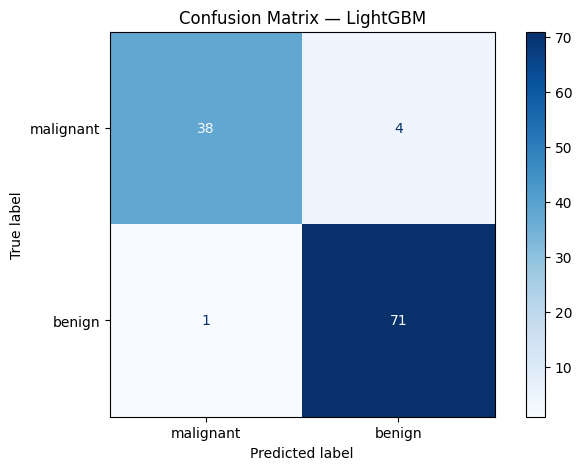

In [42]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap="Blues")
plt.title(f"Confusion Matrix — LightGBM")
plt.show()

## 7. Learning Curve
Зависимость качества от размера обучающей выборки.

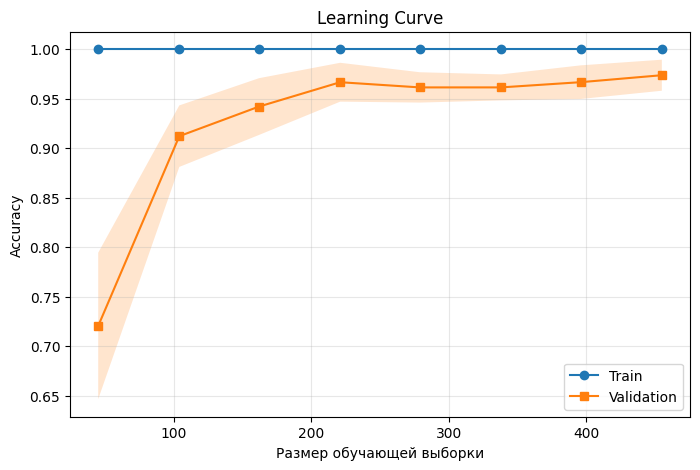

In [43]:
sizes, train_lc, val_lc = learning_curve(
    make_gb(n_estimators=200, learning_rate=0.1),
    X, y, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RND, n_jobs=-1
)

plt.plot(sizes, train_lc.mean(axis=1), "o-", label="Train")
plt.plot(sizes, val_lc.mean(axis=1), "s-", label="Validation")
plt.fill_between(sizes, train_lc.mean(1)-train_lc.std(1), train_lc.mean(1)+train_lc.std(1), alpha=0.2)
plt.fill_between(sizes, val_lc.mean(1)-val_lc.std(1), val_lc.mean(1)+val_lc.std(1), alpha=0.2)
plt.xlabel("Размер обучающей выборки")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Feature Importance
Какие признаки модель считает самыми важными.

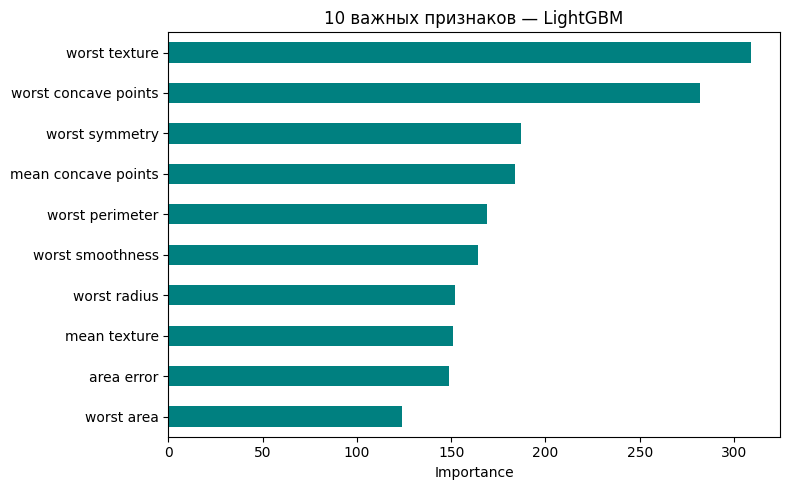

In [44]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(10)

importances.plot(kind="barh", color="teal")
plt.title(f"10 важных признаков — LightGBM")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

## 9. Влияние learning_rate (шаг обучения)
`learning_rate` — насколько сильно очередное дерево корректирует прошлые. Маленький — учится медленно, но стабильнее; большой — быстрее, но риск переобучения.

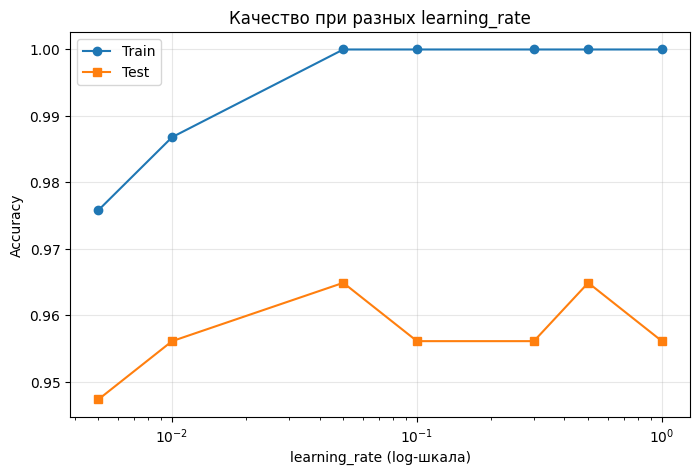

In [46]:
lrs = [0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
lr_train, lr_test = [], []

for lr in lrs:
    m = make_gb(n_estimators=200, learning_rate=lr).fit(X_train, y_train)
    lr_train.append(accuracy_score(y_train, m.predict(X_train)))
    lr_test.append(accuracy_score(y_test, m.predict(X_test)))

plt.plot(lrs, lr_train, "o-", label="Train")
plt.plot(lrs, lr_test, "s-", label="Test")
plt.xscale("log")
plt.xlabel("learning_rate (log-шкала)")
plt.ylabel("Accuracy")
plt.title("Качество при разных learning_rate")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 10. Сравнение: Gradient Boosting vs Random Forest vs AdaBoost

In [47]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RND),
    "AdaBoost":      AdaBoostClassifier(n_estimators=200, random_state=RND),
    "LightGBM":          make_gb(n_estimators=200, learning_rate=0.1),
}

rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    yproba = m.predict_proba(X_test)[:, 1]
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp),
        "Recall":    recall_score(y_test, yp),
        "F1":        f1_score(y_test, yp),
        "ROC-AUC":   roc_auc_score(y_test, yproba),
        "LogLoss":   log_loss(y_test, yproba),
    })

df_cmp = pd.DataFrame(rows).set_index("Model").round(4)
df_cmp

,Accuracy,Precision,Recall,F1,ROC-AUC,LogLoss
Model,,,,,,
Random Forest,0.9561,0.9589,0.9722,0.9655,0.9931,0.1118
AdaBoost,0.9649,0.9474,1.0000,0.9730,0.9864,0.4250
LightGBM,0.9561,0.9467,0.9861,0.9660,0.9891,0.2330


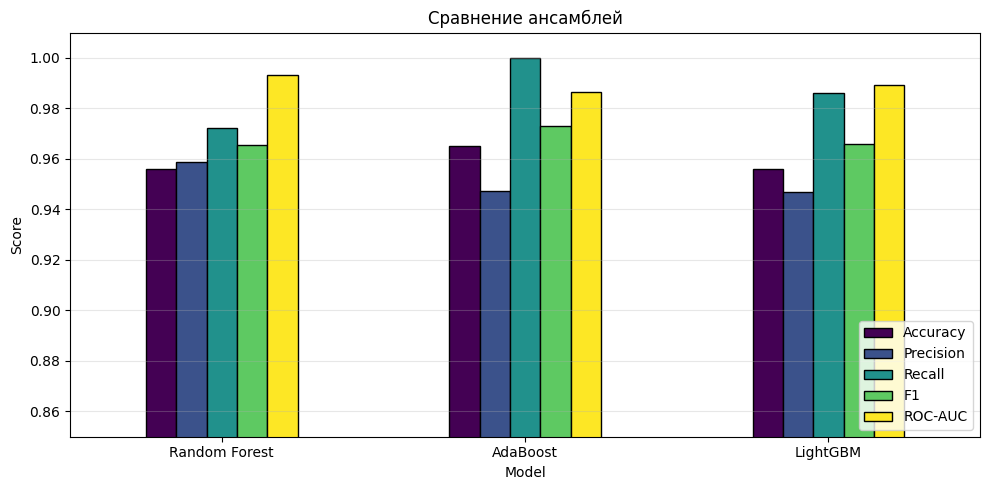

In [48]:
ax = df_cmp[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), colormap="viridis", edgecolor="black"
)
ax.set_title("Сравнение ансамблей")
ax.set_ylabel("Score")
ax.set_ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

#**Общий итог:**

- **Gradient Boosting** строит деревья **последовательно**, каждое исправляет ошибки предыдущих — в отличие от **Random Forest** (параллельные независимые деревья).
- `n_estimators` (количество деревьев) и `learning_rate` (шаг обучения) — **взаимосвязаны**: меньше шаг → нужно больше деревьев.
- Слишком большой `learning_rate` ведёт к переобучению, слишком маленький — к недообучению.
- На большинстве табличных задач **Gradient Boosting обычно даёт лучший ROC-AUC и F1**, чем Random Forest и AdaBoost.